In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
sys.path.append('CAFE')
from CAFE import utils

In [4]:
import graph_analysis
from graph_analysis import CommunityAnalyzer
from community import community_louvain
from collections import Counter

import networkx as nx
import numpy as np

In [5]:
kg = utils.load_kg('beauty')

# Withough Outlier Removal and Community Detection

In [6]:
def report_related_entities_statistics(kg, entities):
    """
    Generates a report on the statistics of the related entities for a given product.
    """
    print("Related Entities Statistics Report:\n")

    # Categories
    num_related_categories = len(entities["category"])
    num_kg_categories = len(kg.G["category"])
    print(f"Number of related categories: {num_related_categories}")
    print(f"Number of categories in the knowledge graph: {num_kg_categories}")
    print(
        f"Percentage of related categories: {num_related_categories / num_kg_categories * 100:.2f}%\n"
    )

    # Brands
    num_related_brands = len(entities["brand"])
    num_kg_brands = len(kg.G["brand"])
    print(f"Number of related brands: {num_related_brands}")
    print(f"Number of brands in the knowledge graph: {num_kg_brands}")
    print(
        f"Percentage of related brands: {num_related_brands / num_kg_brands * 100:.2f}%\n"
    )

    # Words
    num_related_words = len(entities["word"])
    num_kg_words = len(kg.G["word"])
    print(f"Number of related words: {num_related_words}")
    print(f"Number of words in the knowledge graph: {num_kg_words}")
    print(
        f"Percentage of related words: {num_related_words / num_kg_words * 100:.2f}%\n"
    )

    # Related Products
    num_related_products = len(entities["related_product"])
    num_kg_related_products = len(kg.G["related_product"])
    print(f"Number of related products: {num_related_products}")
    print(f"Number of products in the knowledge graph: {num_kg_related_products}")
    print(
        f"Percentage of related products: {num_related_products / num_kg_related_products * 100:.2f}%\n"
    )

In [7]:
def analyze_product_relationships(kg, product_id):
    entities = {'category': set(), 'brand': set(), 'word': set(), 'related_product': set()}
    initial_counts = {'category': 0, 'brand': 0, 'word': 0, 'related_product': 0}
    # detailed_changes = {key: {'category': set(), 'brand': set(), 'word': set(), 'related_product': set()} for key in ['category', 'brand', 'word', 'related_product']}
    detailed_changes = {key: {'category': {'connected':set(), 'new_attributes':set()}, 'brand': {'connected':set(), 'new_attributes':set()},\
                               'word': {'connected':set(), 'new_attributes':set()}, 'related_product': {'connected':set(), 'new_attributes':set()}} for key in ['category', 'brand', 'word', 'related_product']}
    related_products_count = {key: 0 for key in ['category', 'brand', 'word', 'related_product']}


    def update_entities(kg, related_products, entities, context):
        updated_entities = update_entities_from_related_products(kg, related_products)
        for key in ['category', 'brand', 'word', 'related_product']:
            before_update = set(entities[key])  # Copy the set here
            entities[key].update(updated_entities[key])
            detailed_changes[context][key]['connected'].update(updated_entities[key])
            if entities[key] != before_update:
                detailed_changes[context][key]['new_attributes'].update(entities[key] - before_update)

    # Process categories
    category_ids = kg['product'].get(product_id, {}).get('belongs_to', [])
    initial_counts['category'] = len(category_ids)
    for category_id in category_ids:
        related_products = kg['category'].get(category_id, {}).get('rev_belongs_to', [])
        related_products_count['category'] += len(related_products)
        update_entities(kg, related_products, entities, 'category')

    # Process brands
    brand_ids = kg['product'].get(product_id, {}).get('produced_by', [])
    initial_counts['brand'] = len(brand_ids)
    for brand_id in brand_ids:
        related_products = kg['brand'].get(brand_id, {}).get('rev_produced_by', [])
        related_products_count['brand'] += len(related_products)
        update_entities(kg, related_products, entities, 'brand')

    # Process words
    word_ids = kg['product'].get(product_id, {}).get('described_by', [])
    initial_counts['word'] = len(word_ids)
    for word_id in word_ids:
        related_products = kg['word'].get(word_id, {}).get('rev_described_by', [])
        related_products_count['word'] += len(related_products)
        update_entities(kg, related_products, entities, 'word')

    # Process related products directly related to the given product
    related_products_ids = kg['product'].get(product_id, {}).get('also_bought', []) +\
                       kg['product'].get(product_id, {}).get('also_viewed', []) +\
                       kg['product'].get(product_id, {}).get('bought_together', [])
    initial_counts['related_product'] = len(related_products)
    for related_product_id in related_products_ids:
        related_products = kg['related_product'].get(related_product_id, {}).get('rev_also_bought', []) +\
                            kg['related_product'].get(related_product_id, {}).get('rev_also_viewed', []) +\
                            kg['related_product'].get(related_product_id, {}).get('rev_bought_together', [])
        related_products_count['related_product'] += len(related_products)
        update_entities(kg, related_products, entities, 'related_product')
        
    
    # Generate detailed report
    total_entities = {k: len(v) for k, v in entities.items()}
    report = f"Report for product with ID {product_id}:\n"
    for key in ['category', 'brand', 'word', 'related_product']:
        report += f"Initially connected {key}: {initial_counts[key]}, total now connected to {total_entities[key]} products.\n"
        for subkey in ['category', 'brand', 'word', 'related_product']:
            connected = len(detailed_changes[key][subkey]['connected'])
            new_attributes = len(detailed_changes[key][subkey]['new_attributes'])
            # report += f"            number of connected {subkey}: {connected} introduced new,                         {new_attributes} new attributes added\n"
            report += f"            number of connected {subkey:<15}: {connected:<18} introduced, {new_attributes:<6} new attributes added\n"

    return report, entities

def update_entities_from_related_products(kg, related_products):
    entities = {
        'category': set(),
        'brand': set(),
        'word': set(),
        'related_product': set()
    }

    for related_product_id in related_products:
        related_product_info = kg['product'].get(related_product_id, {})
        entities['category'].update(related_product_info.get('belongs_to', []))
        entities['brand'].update(related_product_info.get('produced_by', []))
        entities['word'].update(related_product_info.get('described_by', []))
        entities['related_product'].update(
            related_product_info.get('also_bought', []) +
            related_product_info.get('also_viewed', []) +
            related_product_info.get('bought_together', [])
        )

    return entities


In [8]:
analyzer = CommunityAnalyzer()
graph = analyzer.build_graph(kg.G)

In [9]:
report, entities = analyze_product_relationships(kg.G, 46)

In [10]:
print(report)

Report for product with ID 46:
Initially connected category: 3, total now connected to 172 products.
            number of connected category       : 172                introduced, 172    new attributes added
            number of connected brand          : 350                introduced, 350    new attributes added
            number of connected word           : 15381              introduced, 15381  new attributes added
            number of connected related_product: 25908              introduced, 25908  new attributes added
Initially connected brand: 1, total now connected to 350 products.
            number of connected category       : 10                 introduced, 0      new attributes added
            number of connected brand          : 1                  introduced, 0      new attributes added
            number of connected word           : 321                introduced, 0      new attributes added
            number of connected related_product: 250                introduc

In [11]:
report_related_entities_statistics(kg, entities)

Related Entities Statistics Report:

Number of related categories: 172
Number of categories in the knowledge graph: 172
Percentage of related categories: 100.00%

Number of related brands: 350
Number of brands in the knowledge graph: 350
Percentage of related brands: 100.00%

Number of related words: 15381
Number of words in the knowledge graph: 15381
Percentage of related words: 100.00%

Number of related products: 25908
Number of products in the knowledge graph: 25908
Percentage of related products: 100.00%



# Degree Centrality of Different Types of Nodes

In [12]:
import networkx as nx

def adjusted_degree_centrality(G, number_of_products=592):
    # Calculate raw degree centrality for all nodes
    raw_centrality = G.degree()

    # Count the total number of nodes except 'product' type nodes
    non_product_nodes = sum(1 for n in G.nodes if not n.startswith('product'))
    
    # Initialize the centrality dictionary
    centrality = {}

    # Apply different normalization based on node type
    for node, degree in raw_centrality:
        if node.startswith('product'):
            # Normalize by the number of non-product nodes
            centrality[node] = degree / non_product_nodes
        else:
            # Normalize by the number of products
            centrality[node] = degree / number_of_products

    return centrality


In [13]:
degree_centrality = adjusted_degree_centrality(graph, len(kg.G['product']))

In [14]:
node_types = set()
node_type_centralities = {}

for node, centrality in degree_centrality.items():
    node_type, node_id = node.rsplit('_', 1)
    node_types.add(node_type)
    if node_type not in node_type_centralities:
        node_type_centralities[node_type] = []
    node_type_centralities[node_type].append((node, centrality))

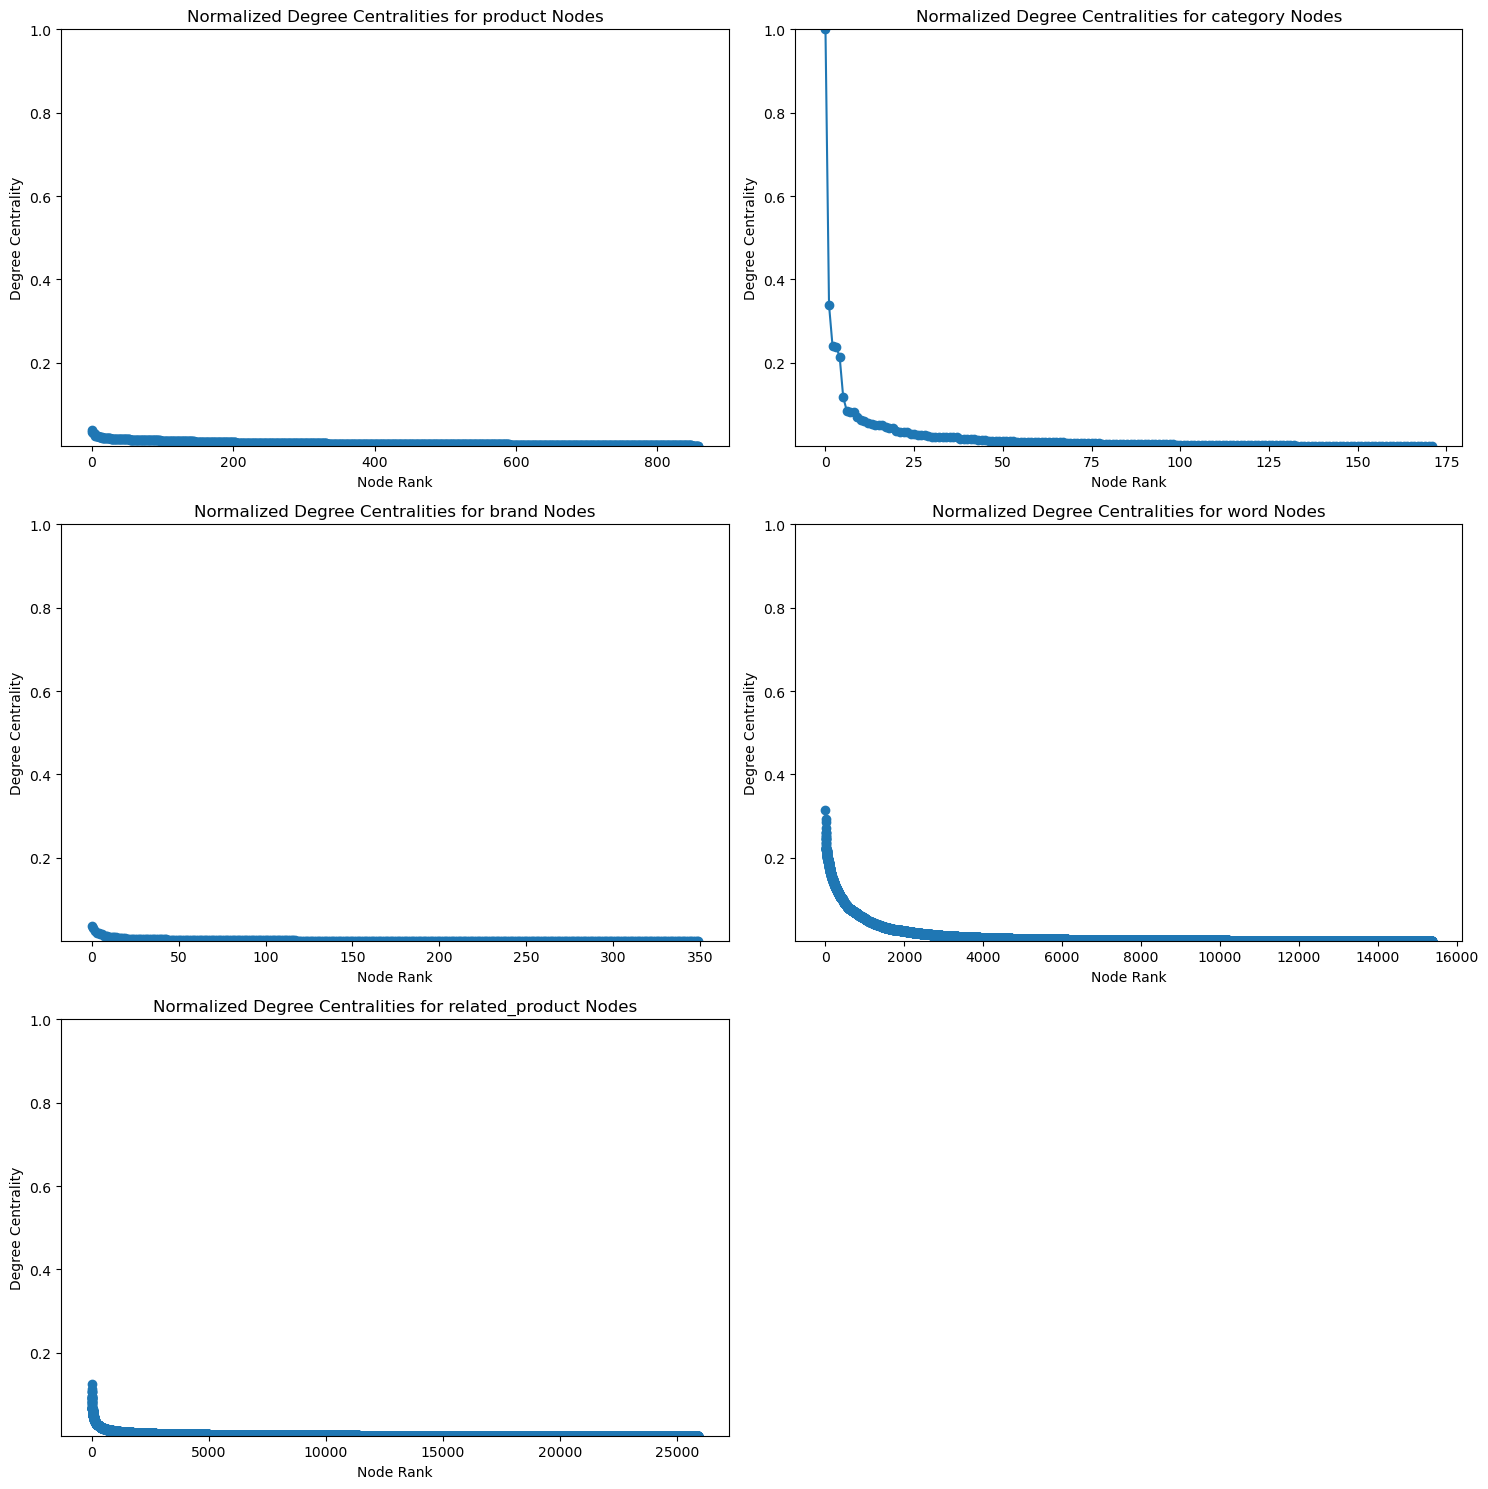

In [15]:
import matplotlib.pyplot as plt
import numpy as np

node_types = list(node_type_centralities.keys())

# Sort the degree centralities for each node type
for node_type in node_type_centralities:
    node_type_centralities[node_type].sort(key=lambda x: x[1], reverse=True)

# Function to calculate outlier bounds
def calculate_bounds(data):
    centrality_values = np.array([x[1] for x in data])
    Q1 = np.percentile(centrality_values, 25)
    Q3 = np.percentile(centrality_values, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

# Determine the number of subplots needed
num_types = len(node_types)
# Set up a 2x2 grid of subplots
fig, axs = plt.subplots(3, 2, figsize=(15, 15))
axs = axs.flatten()

# Determine global minimum and maximum for consistent y-axis scale
all_centrality_values = [value for centralities in node_type_centralities.values() for _, value in centralities]
global_lower_bound = min(all_centrality_values)
global_upper_bound = max(all_centrality_values)

# Plotting each node type in a separate subplot
for ax, node_type in zip(axs, node_type_centralities):
    centralities = node_type_centralities[node_type]
    if centralities:
        nodes, centrality_values = zip(*centralities)
        ax.plot(range(len(centrality_values)), centrality_values, marker='o')
        # Calculate and plot bounds (optional, commented out)
        # lower_bound, upper_bound = calculate_bounds(centralities)
        # ax.axhline(y=lower_bound, color='red', linestyle='--', label='Lower Bound')
        # ax.axhline(y=upper_bound, color='green', linestyle='--', label='Upper Bound')
    ax.set_xlabel('Node Rank')
    ax.set_ylabel('Degree Centrality')
    ax.set_title(f'Normalized Degree Centralities for {node_type} Nodes')
    ax.set_ylim(global_lower_bound, global_upper_bound)  # Setting the same y-axis limits
    # ax.legend()

# If there are less than 4 node types, hide the unused subplots
for ax in axs[len(node_type_centralities):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


# Outlier Bounds

In [16]:
import networkx as nx
import numpy as np

def calculate_outlier_bounds(centrality_values, method='std_dev', num_std_dev=2, top_n=10, top_percentile=95):
    """
    Calculate the bounds or identify outliers based on centrality values using specified methods.

    Parameters:
    - centrality_values: List of centrality values.
    - method: Method to use for outlier calculation ('std_dev', 'top_n', 'iqr', 'percentile').
    - num_std_dev: Number of standard deviations to use as the cutoff (used if method='std_dev').
    - top_n: Number of top highest centrality nodes to identify (used if method='top_n').
    - top_percentile: Percentile for identifying top centrality nodes (used if method='percentile').

    Returns:
    - A tuple (lower_bound, upper_bound) for 'std_dev' and 'iqr' methods.
    - A list of top_n outliers for 'top_n' method.
    - A list of outliers for 'percentile' method.
    """
    if method == 'std_dev':
        mean_centrality = np.mean(centrality_values)
        std_dev_centrality = np.std(centrality_values)
        lower_bound = mean_centrality - num_std_dev * std_dev_centrality
        upper_bound = mean_centrality + num_std_dev * std_dev_centrality
        return lower_bound, upper_bound
    elif method == 'top_n':
        sorted_centralities = sorted(centrality_values, reverse=True)
        return sorted_centralities[:top_n]
    elif method == 'iqr':
        Q1 = np.percentile(centrality_values, 25)
        Q3 = np.percentile(centrality_values, 75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        return lower_bound, upper_bound
    elif method == 'percentile':
        threshold = np.percentile(centrality_values, top_percentile)
        return [value for value in centrality_values if value >= threshold]
    else:
        raise ValueError("Invalid method specified. Choose 'std_dev', 'top_n', 'iqr', or 'percentile'.")

def identify_outliers(centrality_dict, method='std_dev', num_std_dev=2, top_n=10, top_percentile=95):
    """
    Identify outliers from the centrality values using specified methods.

    Parameters:
    - centrality_dict: Dictionary of centrality values of the nodes in a graph.
    - method: Method to use for outlier identification ('std_dev', 'top_n', 'iqr', 'percentile').
    - num_std_dev: Number of standard deviations to use as the cutoff (used if method='std_dev').
    - top_n: Number of top highest centrality nodes to identify as outliers (used if method='top_n').
    - top_percentile: Percentile for identifying top centrality nodes (used if method='percentile').

    Returns:
    - A dictionary of outlier nodes and their centrality values.
    - A tuple (lower_bound, upper_bound) or list of top_n outliers or percentile outliers based on the method.
    """
    centrality_values = list(centrality_dict.values())

    if method in ['std_dev', 'iqr', 'percentile']:
        bounds_or_outliers = calculate_outlier_bounds(centrality_values, method, num_std_dev, top_n, top_percentile)
        if method == 'percentile':
            outliers = {node: centrality for node, centrality in centrality_dict.items() if centrality >= bounds_or_outliers[0]}
            return outliers, bounds_or_outliers
        else:
            lower_bound, upper_bound = bounds_or_outliers
            outliers = {node: centrality for node, centrality in centrality_dict.items() if centrality < lower_bound or centrality > upper_bound}
            return outliers, (lower_bound, upper_bound)
    elif method == 'top_n':
        top_n_outliers = calculate_outlier_bounds(centrality_values, method, num_std_dev, top_n)
        outliers = {node: centrality for node, centrality in sorted(centrality_dict.items(), key=lambda item: item[1], reverse=True)[:top_n]}
        return outliers, top_n_outliers
    else:
        raise ValueError("Invalid method specified. Choose 'std_dev', 'top_n', 'iqr', or 'percentile'.")


In [17]:
outliers, (lower_bound, upper_bound) = identify_outliers(degree_centrality, method='std_dev', num_std_dev=2, top_n=10)

## Outlier Removal Analysis

In [18]:
def calculate_modularity(G):
    # Detect communities
    partition = community_louvain.best_partition(G, random_state=42)
    # Calculate the modularity
    modularity = community_louvain.modularity(partition, G)
    return modularity

def compare_modularity(G, cleaned_G):
    old_modularity = calculate_modularity(G)
    new_modularity = calculate_modularity(cleaned_G)
    print()
    print(f'The modularity of the original Graph: {old_modularity}')
    print(f'The modularity of the cleaned Graph: {new_modularity}')
    print()

In [19]:
from kneed import KneeLocator

def remove_centrality_outliers(G, centrality_dict, method='std_dev', num_std_dev=2, top_n=10, top_percentile=95):
    """
    Remove outliers from the graph G based on centrality values using specified methods and return the removed nodes.

    Parameters:
    - G: A NetworkX graph.
    - centrality_dict: Dictionary of centrality values of the nodes in G.
    - method: Method to use for outlier removal ('std_dev', 'top_n', 'iqr', 'percentile', 'knee').
    - num_std_dev: Number of standard deviations to use as the cutoff (used if method='std_dev').
    - top_n: Number of top highest centrality nodes to remove (used if method='top_n').
    - top_percentile: Percentile threshold to use for outlier removal (used if method='percentile').

    Returns:
    - A new graph with outliers removed.
    - A dictionary of removed nodes and their centrality values.
    """
    centrality_values = list(centrality_dict.values())
    removed_nodes = {}

    if method == 'std_dev':
        mean_centrality = np.mean(centrality_values)
        std_dev_centrality = np.std(centrality_values)
        lower_bound = mean_centrality - num_std_dev * std_dev_centrality
        upper_bound = mean_centrality + num_std_dev * std_dev_centrality
        for node, centrality in centrality_dict.items():
            if centrality < lower_bound or centrality > upper_bound:
                removed_nodes[node] = centrality
    elif method == 'top_n':
        sorted_centralities = sorted(centrality_dict.items(), key=lambda item: item[1], reverse=True)
        for node, centrality in sorted_centralities[:top_n]:
            removed_nodes[node] = centrality
    elif method == 'iqr':
        Q1 = np.percentile(centrality_values, 25)
        Q3 = np.percentile(centrality_values, 75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        for node, centrality in centrality_dict.items():
            if centrality < lower_bound or centrality > upper_bound:
                removed_nodes[node] = centrality
    elif method == 'percentile':
        threshold = np.percentile(centrality_values, top_percentile)
        for node, centrality in centrality_dict.items():
            if centrality >= threshold:
                removed_nodes[node] = centrality
    elif method == 'knee':
        y = sorted(centrality_values, reverse=True)
        x = np.arange(len(y))
        knee = KneeLocator(x, y, curve='convex', direction='decreasing')
        knee_point = knee.knee_y
        for node, centrality in centrality_dict.items():
            if centrality >= knee_point:
                removed_nodes[node] = centrality
    else:
        raise ValueError("Invalid method specified. Choose 'std_dev', 'top_n', 'iqr', 'percentile', or 'knee'.")

    # Create a new graph without outliers
    G_new = G.copy()
    nodes_to_remove = set(removed_nodes.keys())
    # TODO: does this remove the edges too? is this consistent?
    G_new.remove_nodes_from(nodes_to_remove)


    return G_new, removed_nodes


In [27]:
def analyze_community_sizes(partition):
    # Calculate the sizes of each community
    sizes = [len(community) for community in partition]
    
    # Compute mean and standard deviation of community sizes
    mean_size = np.mean(sizes)
    std_dev = np.std(sizes)
    
    # print(f"Average community size: {mean_size}")
    # print(f"Standard deviation of sizes: {std_dev}")
    
    # Define thresholds for large and small communities based on mean and standard deviation
    large_threshold = mean_size + 2 * std_dev
    small_threshold = mean_size - 2 * std_dev
    
    # Identify large and small communities
    # large_communities = [community for community in partition if len(community) > large_threshold]
    # small_communities = [community for community in partition if len(community) < small_threshold]
    
    # Output the sizes of large and small communities for verification
    # print("Large communities (sizes):", [len(community) for community in large_communities])
    # print("Small communities (sizes):", [len(community) for community in small_communities])
    print(f"Minimum community size: {min(sizes)}")
    print(f"Maximum community size: {max(sizes)}")

    # return large_communities, small_communities

In [28]:
def analyze_graph_and_communities(G, centrality_dict, method='top_n', top_n=10, num_std_dev=2, top_percentile=95):
    """
    Cleans the graph based on specified outlier removal method, analyzes community structures,
    and plots the distribution of community sizes and removed node centrality values.
    
    Parameters:
    - G: A NetworkX graph.
    - centrality_dict: Dictionary of centrality values of the nodes in G.
    - method: Method for outlier removal ('std_dev', 'top_n', 'iqr').
    - top_n: Number of top highest centrality nodes to remove if method='top_n'.
    """
    # Remove outliers based on centrality and get the cleaned graph and removed nodes
    G_clean, removed_nodes = remove_centrality_outliers(G, centrality_dict, method=method, top_n=top_n, num_std_dev=num_std_dev, top_percentile=top_percentile)

    print("Size of the cleaned graph:", len(G_clean))
    print("Original graph size:", len(G))
    # Compare the sizes of original and cleaned graphs
    print("Nodes removed:", len(G) - len(G_clean))

    # compare_modularity(G, G_clean)  # Assuming a function 'compare_modularity' exists

    # Community detection using Louvain method on cleaned graph
    partition_clean = community_louvain.best_partition(G_clean, random_state=42)
    community_sizes_clean = Counter(partition_clean.values())
    print("Number of communities in cleaned graph:", len(community_sizes_clean))

    # Community detection on original graph
    partition_original = community_louvain.best_partition(G, random_state=42)
    community_sizes_original = Counter(partition_original.values())
    print("Number of communities in original graph:", len(community_sizes_original))


    # Organize nodes by community
    community_dict = {}
    for node, community_id in partition_clean.items():
        if community_id not in community_dict:
            community_dict[community_id] = set()
        community_dict[community_id].add(node)
    community_list = list(community_dict.values())


    # Calculate the combined range from both datasets
    combined_range = (min(min(community_sizes_original.values()), min(community_sizes_clean.values())),
                    max(max(community_sizes_original.values()), max(community_sizes_clean.values())))

    plt.figure(figsize=(10, 10))
    plt.hist(list(community_sizes_original.values()), bins=10, alpha=1, label='Original', edgecolor='black', range=combined_range)
    plt.hist(list(community_sizes_clean.values()), bins=10, alpha=0.5, label='Cleaned', edgecolor='black', range=combined_range)
    plt.title('Original and Cleanded Graphs Community Sizes Comparison')
    plt.xlabel('Community Size')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

    # Analyze community sizes
    analyze_community_sizes(community_list)  # Assuming a function 'analyze_community_sizes' exists

    # Sort removed nodes by centrality values
    sorted_removed_nodes = dict(sorted(removed_nodes.items(), key=lambda item: item[1], reverse=True))

    # Plotting histogram of centrality values of removed nodes
    plt.figure(figsize=(10, 6))
    plt.hist(list(sorted_removed_nodes.values()), bins=10, color='skyblue', edgecolor='black')
    plt.title('Removed Nodes Degree Centrality Distribution')
    plt.xlabel('Degree Centrality Value')
    plt.ylabel('Frequency')
    plt.show()


### Outlier Removal with Standard Deviation

Size of the cleaned graph: 41391
Original graph size: 42670
Nodes removed: 1279
Number of communities in cleaned graph: 22
Number of communities in original graph: 22


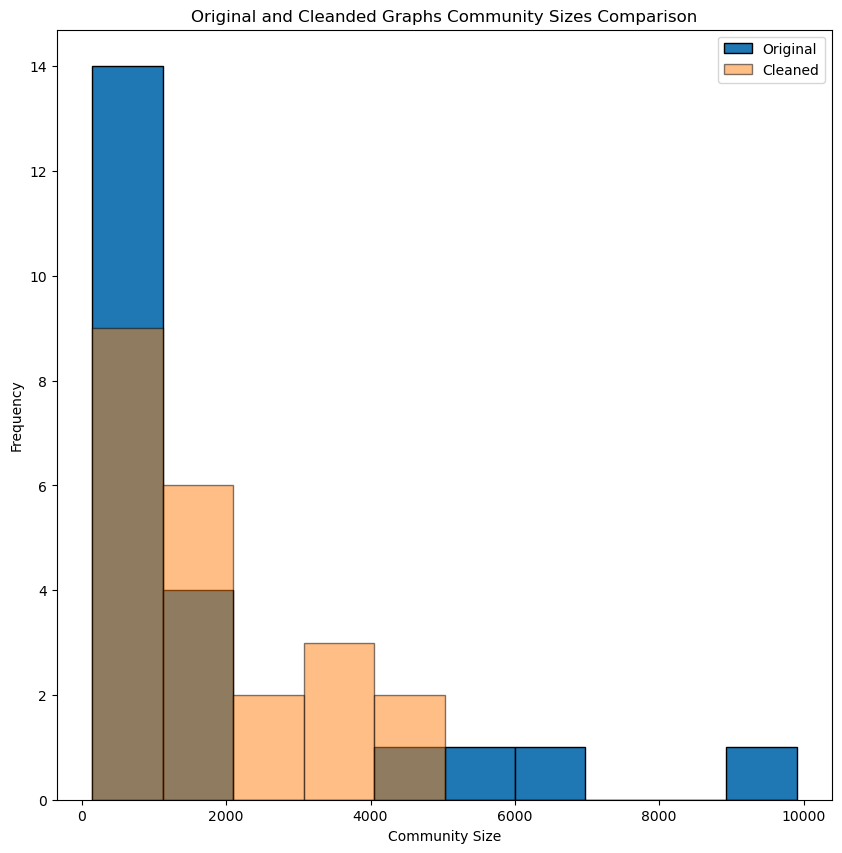

Minimum community size: 144
Maximum community size: 5018


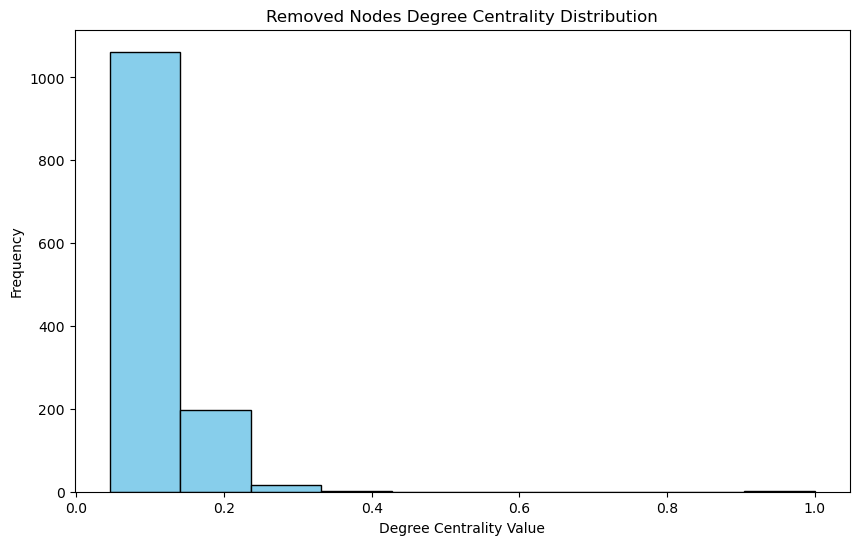

In [29]:
analyze_graph_and_communities(graph, degree_centrality, method='std_dev', num_std_dev=2)

### Outlier Removal with Percentile

Size of the cleaned graph: 40533
Original graph size: 42670
Nodes removed: 2137
Number of communities in cleaned graph: 398
Number of communities in original graph: 22


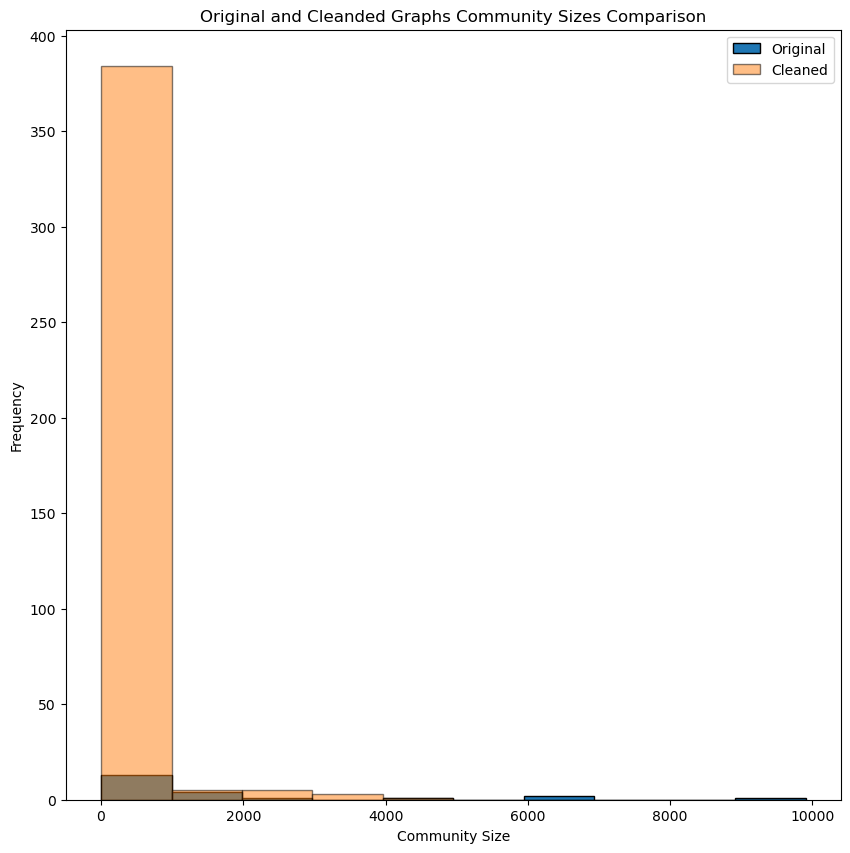

Minimum community size: 1
Maximum community size: 4144


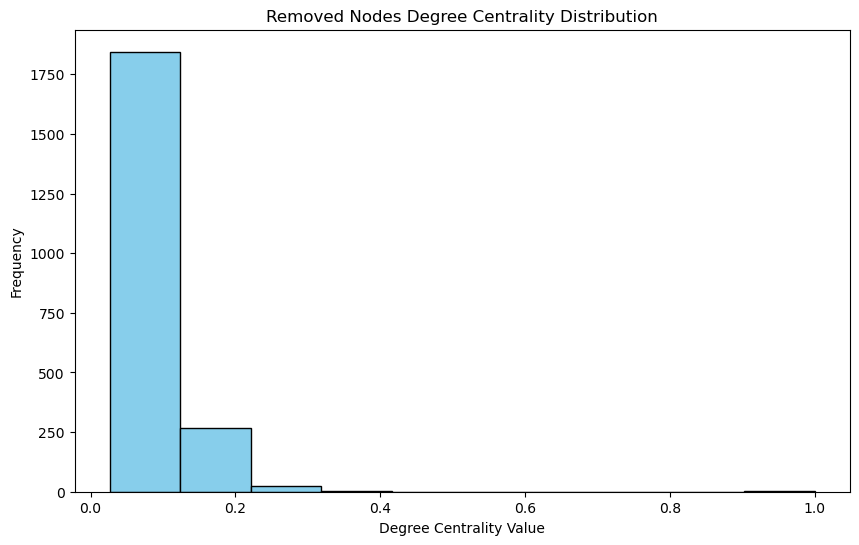

In [30]:
analyze_graph_and_communities(graph, degree_centrality, method='percentile')

### Outlier Removal with Interquartile Range

Size of the cleaned graph: 37429
Original graph size: 42670
Nodes removed: 5241
Number of communities in cleaned graph: 6559
Number of communities in original graph: 22


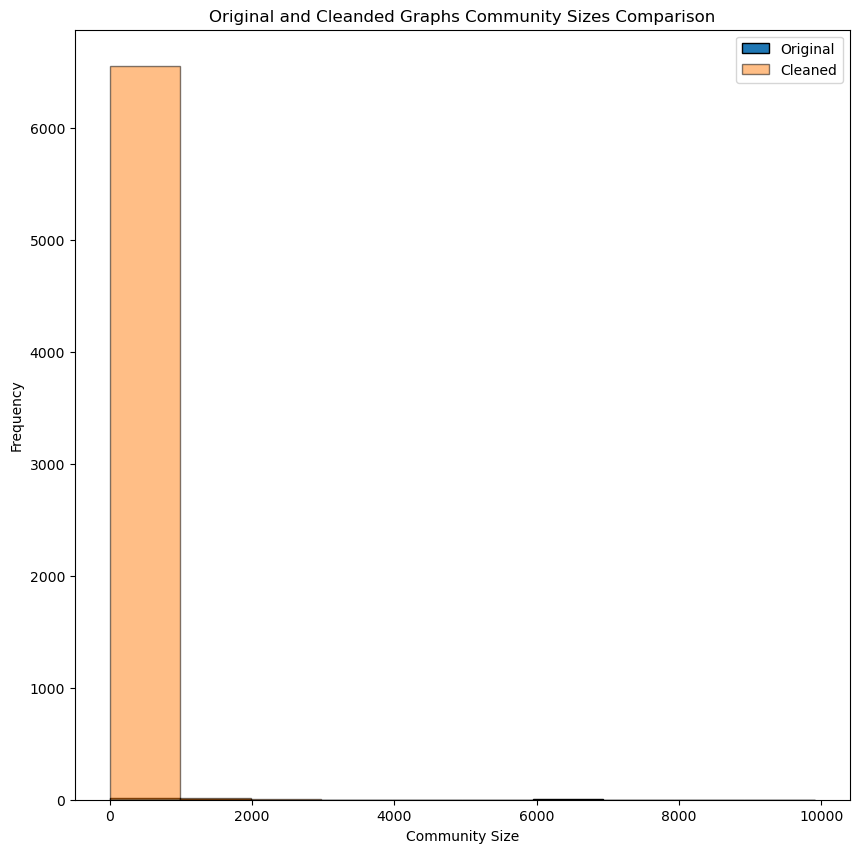

Minimum community size: 1
Maximum community size: 2130


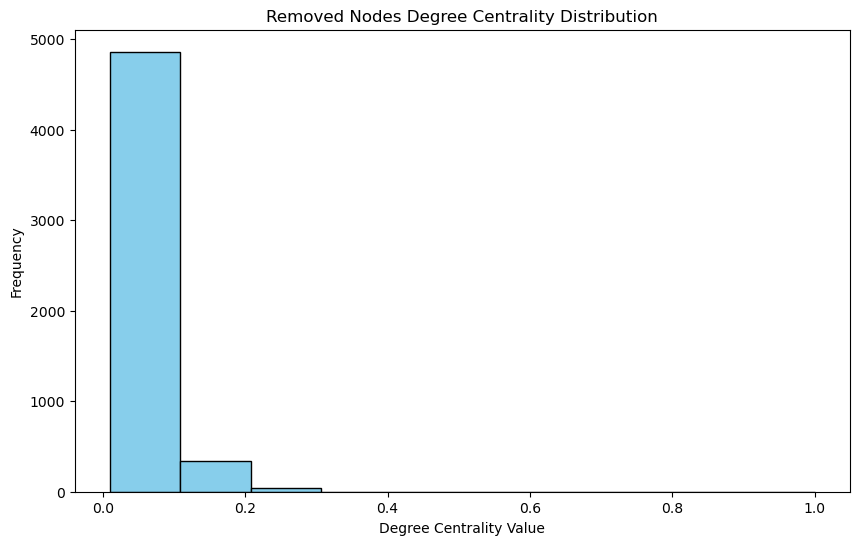

In [31]:
analyze_graph_and_communities(graph, degree_centrality, method='iqr')

### Outlier Removal with Knee Method

Size of the cleaned graph: 42645
Original graph size: 42670
Nodes removed: 25
Number of communities in cleaned graph: 24
Number of communities in original graph: 22


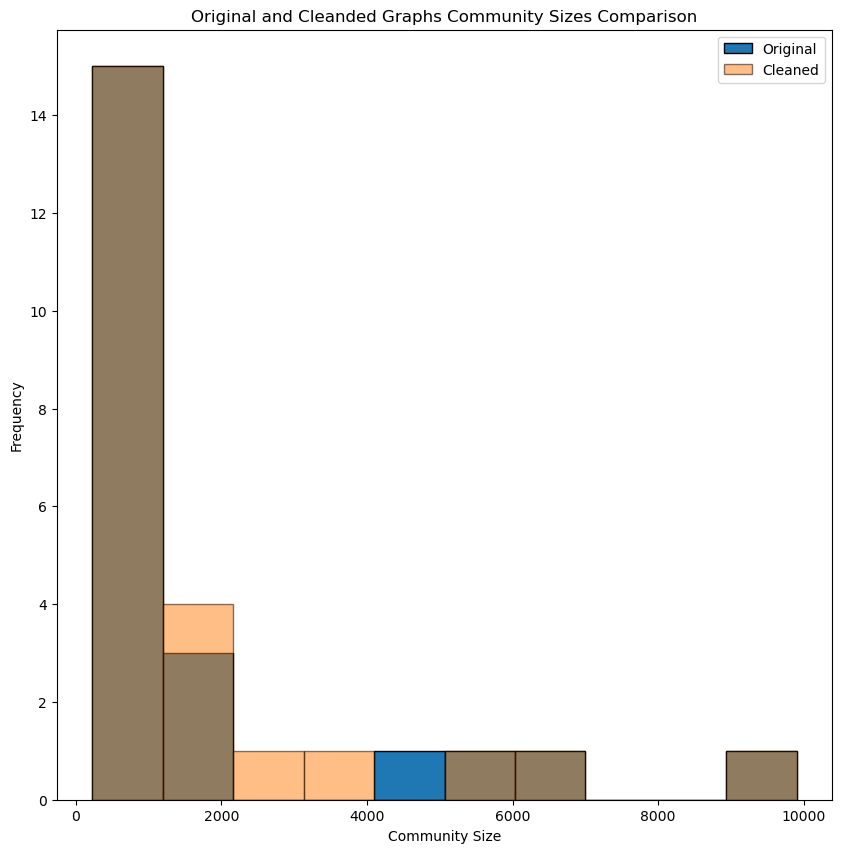

Minimum community size: 225
Maximum community size: 9464


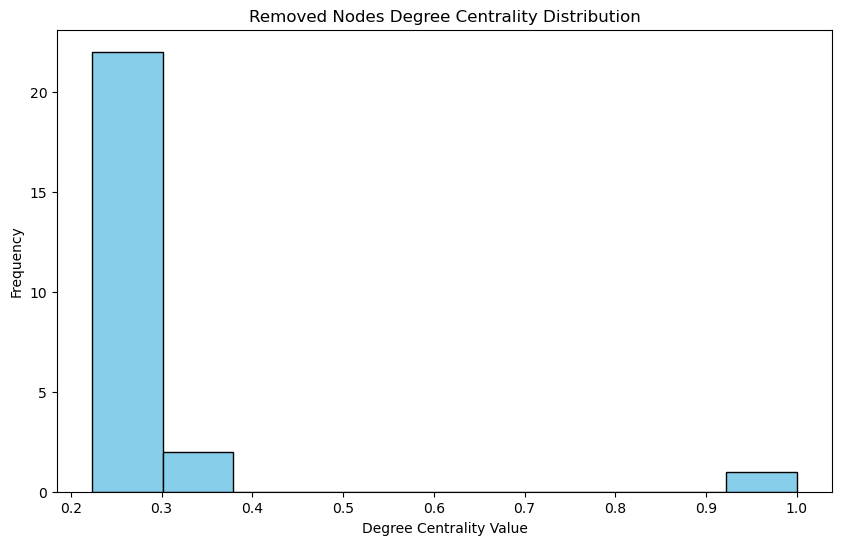

In [32]:
analyze_graph_and_communities(graph, degree_centrality, method='knee')

### Outlier Removal with Top-N Method

Size of the cleaned graph: 42650
Original graph size: 42670
Nodes removed: 20
Number of communities in cleaned graph: 19
Number of communities in original graph: 22


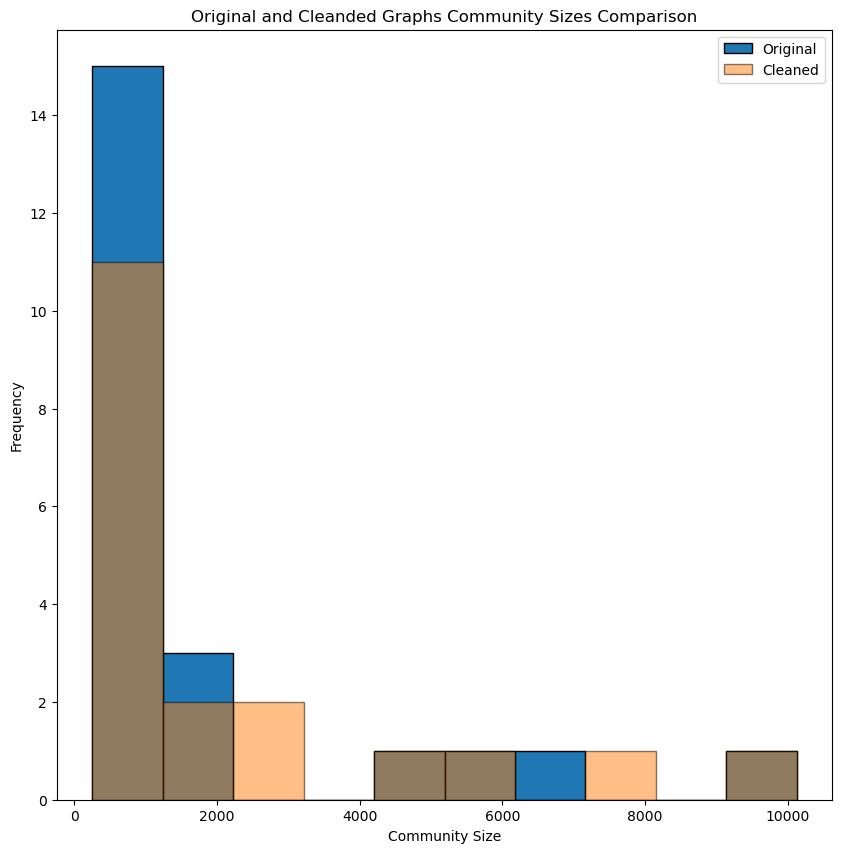

Minimum community size: 251
Maximum community size: 10130


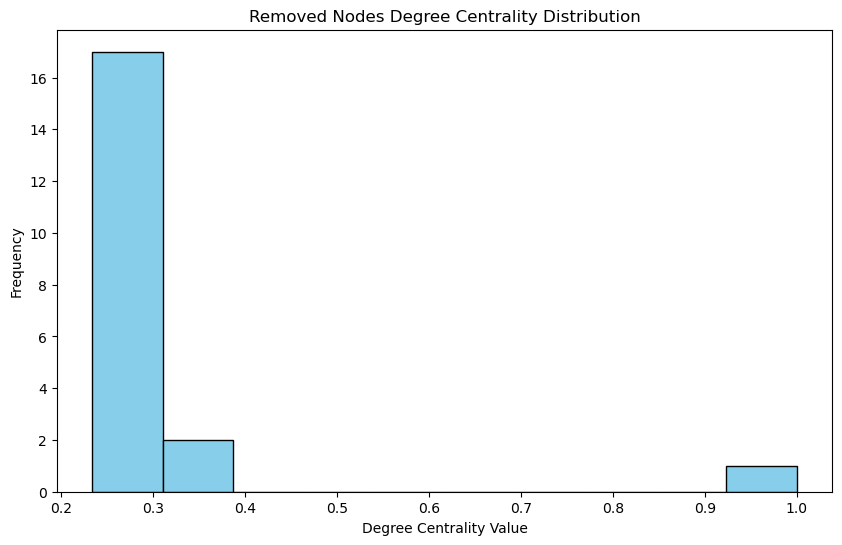

In [33]:
analyze_graph_and_communities(graph, degree_centrality, method='top_n', top_n=20)

## Knee Method in Outlier Detection

The elbow is located at index: 21, Degree centrality: 0.22351571594877764


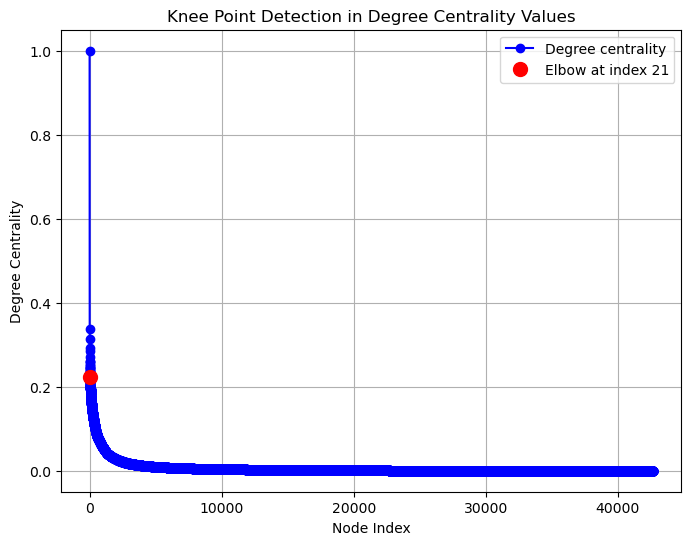

In [34]:
import numpy as np
from kneed import KneeLocator
import matplotlib.pyplot as plt

# Example data: degree centrality values sorted in descending order
y = sorted(list(degree_centrality.values()), reverse=True)
x = np.arange(0, len(y))

# Instantiate the KneeLocator
knee = KneeLocator(x, y, curve='convex', direction='decreasing')

# Finding the elbow
elbow_point = knee.knee
print(f"The elbow is located at index: {elbow_point}, Degree centrality: {y[elbow_point]}")

# Plotting the degree centrality values
plt.figure(figsize=(8, 6))
plt.plot(x, y, 'b-', marker='o', label='Degree centrality')
plt.xlabel('Node Index')
plt.ylabel('Degree Centrality')
plt.title('Knee Point Detection in Degree Centrality Values')

# Highlighting the knee point
plt.plot(elbow_point, y[elbow_point], 'ro', markersize=10, label=f'Elbow at index {elbow_point}')
plt.legend()
plt.grid(True)
plt.show()